In [1]:
import numpy as np 
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
from matplotlib import *
%matplotlib inline
import seaborn as sns
import re

print('OK')



OK


In [2]:
#Opening Data
data= pd.read_csv('../input/fifa19/data.csv', index_col=0) 
data.head()

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,https://cdn.sofifa.org/teams/2/light/241.png,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,https://cdn.sofifa.org/teams/2/light/45.png,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,https://cdn.sofifa.org/teams/2/light/73.png,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,https://cdn.sofifa.org/teams/2/light/11.png,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,https://cdn.sofifa.org/teams/2/light/10.png,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


In [3]:
#Data Size(Rows, Columns)
data.shape

(18207, 88)

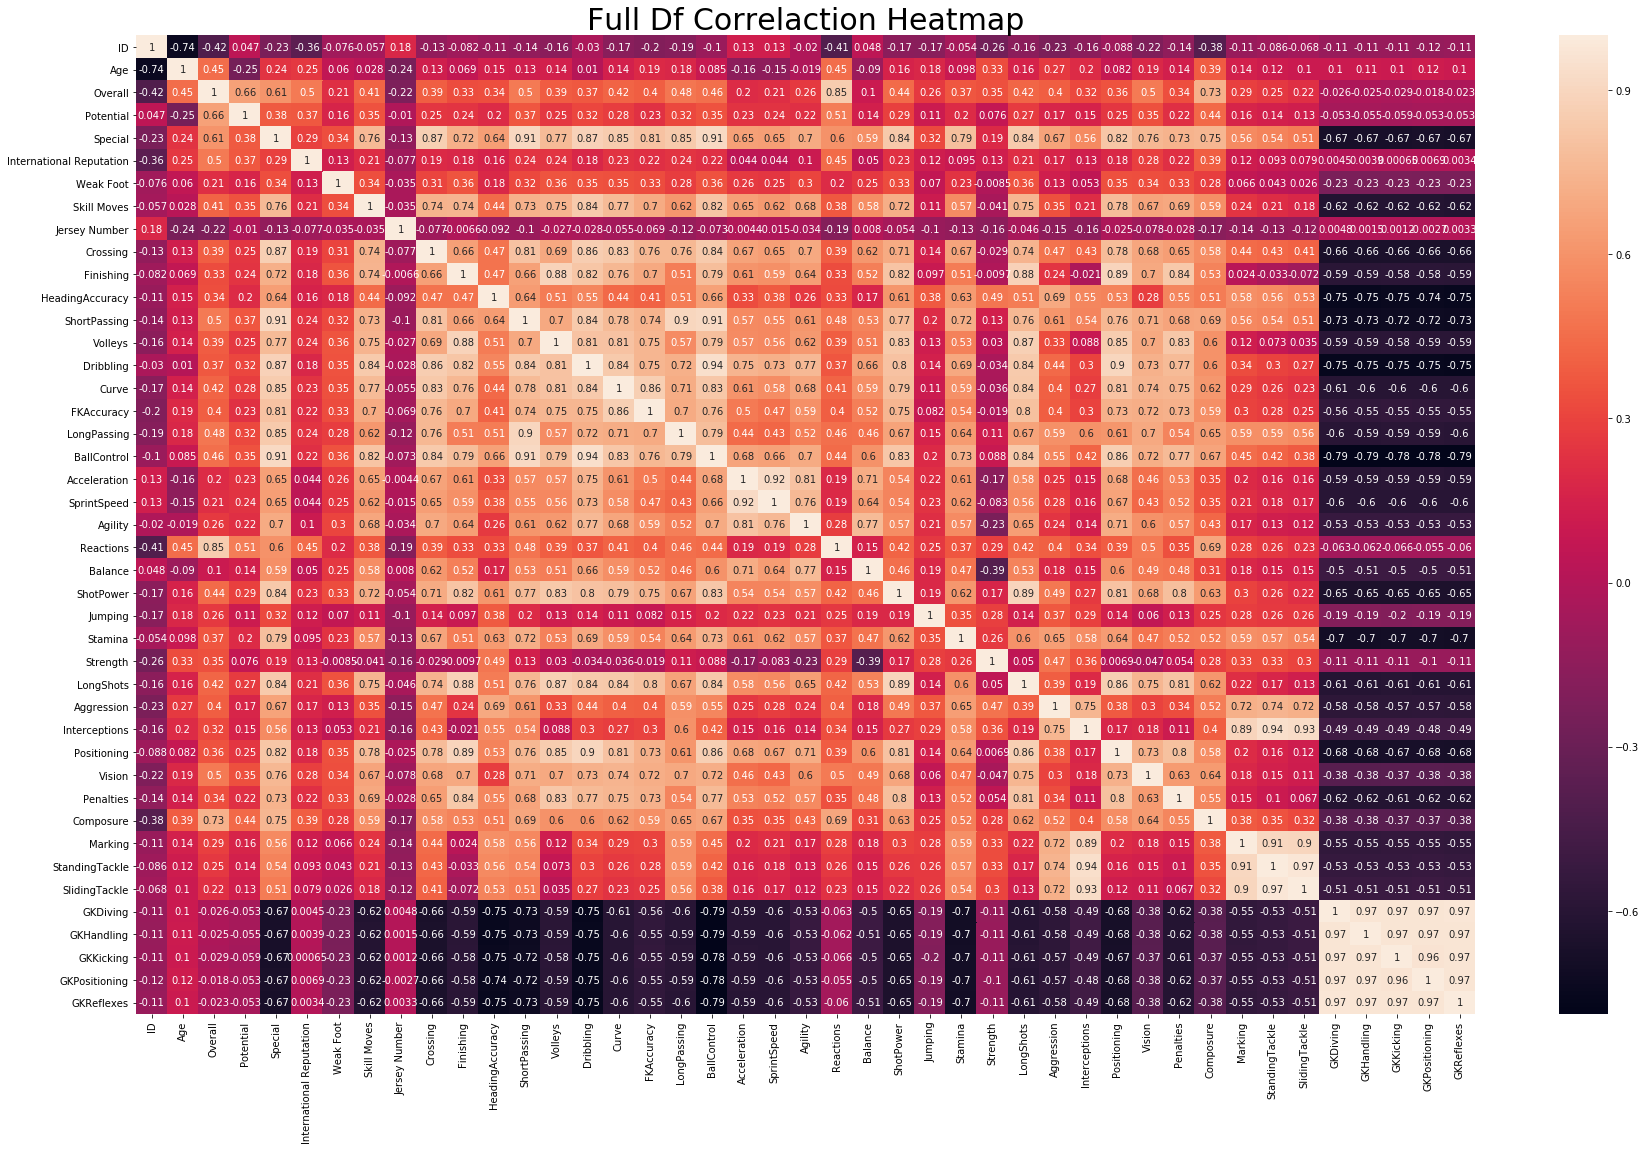

In [4]:
#Data Correlaction
data_corr= data.corr()
plt.figure(figsize= (30,18))
sns.heatmap(data= data_corr, annot= True)
plt.title('Full Df Correlaction Heatmap', fontsize= 30)
plt.show()

***Cleaning Data***

In [5]:
#All Data collumns
data.columns

Index(['ID', 'Name', 'Age', 'Photo', 'Nationality', 'Flag', 'Overall',
       'Potential', 'Club', 'Club Logo', 'Value', 'Wage', 'Special',
       'Preferred Foot', 'International Reputation', 'Weak Foot',
       'Skill Moves', 'Work Rate', 'Body Type', 'Real Face', 'Position',
       'Jersey Number', 'Joined', 'Loaned From', 'Contract Valid Until',
       'Height', 'Weight', 'LS', 'ST', 'RS', 'LW', 'LF', 'CF', 'RF', 'RW',
       'LAM', 'CAM', 'RAM', 'LM', 'LCM', 'CM', 'RCM', 'RM', 'LWB', 'LDM',
       'CDM', 'RDM', 'RWB', 'LB', 'LCB', 'CB', 'RCB', 'RB', 'Crossing',
       'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling',
       'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration',
       'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'ShotPower',
       'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression',
       'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure',
       'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiv

In [6]:
drop= data.drop(columns=['Flag','Club Logo','Photo','ID','Composure','Marking','StandingTackle','GKDiving','GKHandling','GKKicking',
                      'GKPositioning','GKReflexes','Stamina','Strength','LongShots','Aggression','Interceptions','Positioning','Vision','Penalties',
                      'SlidingTackle','LongPassing','BallControl','Acceleration','SprintSpeed','Agility','Reactions','Balance','ShotPower',
                      'Jumping','RB','Crossing','Finishing','HeadingAccuracy','ShortPassing','Volleys','Dribbling','Curve','FKAccuracy',
                      'LWB','LDM','CDM','RDM','RWB','LB','LCB','CB','RCB','RW','LAM','CAM','RAM','LM','LCM','CM','RCM','RM','ST','RS','LW',
                      'LF','CF','RF','Joined','Loaned From','Skill Moves','Work Rate','Weak Foot','LS','Body Type','Real Face','Special', 'Release Clause'])

#Renaming columns
df= drop.rename(columns={'Preferred Foot':'Preferred_Foot', 'International Reputation':
                         'International_Reputation', 'Jersey Number': 'Jersey_Number', 
                         'Contract Valid Until':'Contract_Valid_Until'})
df.head()

,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred_Foot,International_Reputation,Position,Jersey_Number,Contract_Valid_Until,Height,Weight
0,L. Messi,31,Argentina,94,94,FC Barcelona,€110.5M,€565K,Left,5.0,RF,10.0,2021,5'7,159lbs
1,Cristiano Ronaldo,33,Portugal,94,94,Juventus,€77M,€405K,Right,5.0,ST,7.0,2022,6'2,183lbs
2,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,€118.5M,€290K,Right,5.0,LW,10.0,2022,5'9,150lbs
3,De Gea,27,Spain,91,93,Manchester United,€72M,€260K,Right,4.0,GK,1.0,2020,6'4,168lbs
4,K. De Bruyne,27,Belgium,91,92,Manchester City,€102M,€355K,Right,4.0,RCM,7.0,2023,5'11,154lbs


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18207 entries, 0 to 18206
Data columns (total 15 columns):
Name                        18207 non-null object
Age                         18207 non-null int64
Nationality                 18207 non-null object
Overall                     18207 non-null int64
Potential                   18207 non-null int64
Club                        17966 non-null object
Value                       18207 non-null object
Wage                        18207 non-null object
Preferred_Foot              18159 non-null object
International_Reputation    18159 non-null float64
Position                    18147 non-null object
Jersey_Number               18147 non-null float64
Contract_Valid_Until        17918 non-null object
Height                      18159 non-null object
Weight                      18159 non-null object
dtypes: float64(2), int64(3), object(10)
memory usage: 2.2+ MB


***Let's Look The Countries***

In [8]:
#How many countries does Fifa 19 has?
df.Nationality.nunique()

164

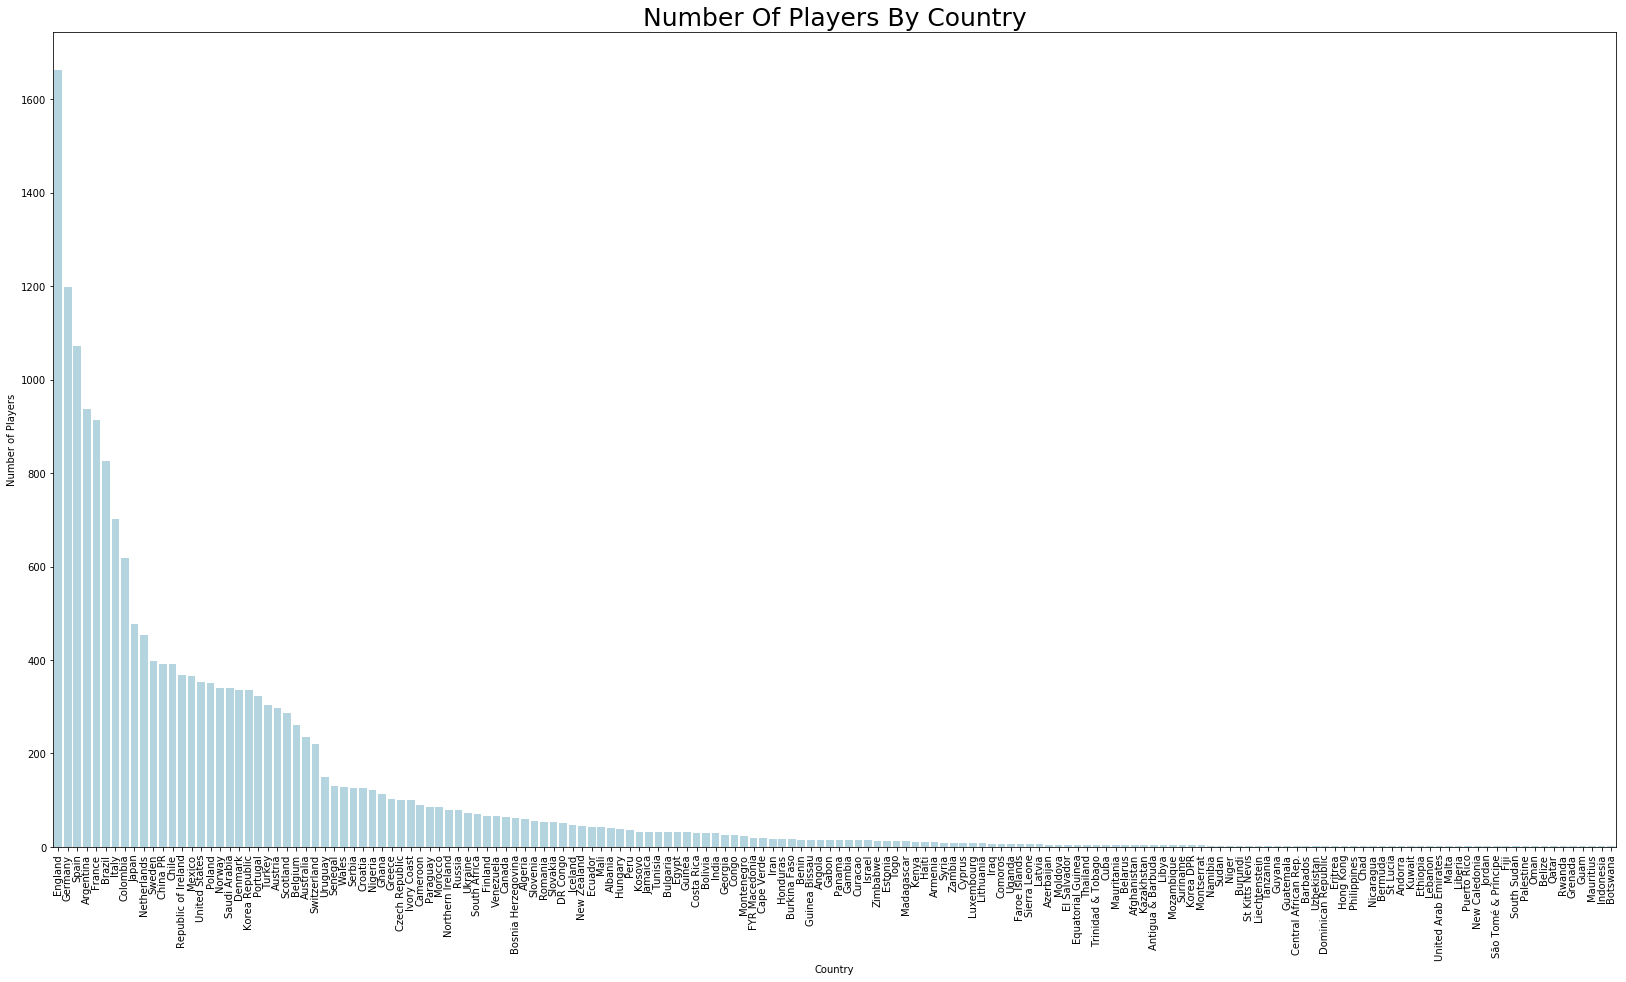

In [9]:
#Number Of Players By Country
country_data= data.Nationality.value_counts()
country= pd.DataFrame(country_data)
country.reset_index(level=0 , inplace=True)
country_count= country.rename(columns= {'index': 'Country', 'Nationality': 'Number of Players'})

#Plotting
plt.figure(figsize = (28,15))
sns.barplot(data=country_count, x='Country', y='Number of Players', color= 'lightblue')
plt.title('Number Of Players By Country', fontsize= 25)
sns.set_style("whitegrid")
plt.xticks(rotation= 90)
plt.show()

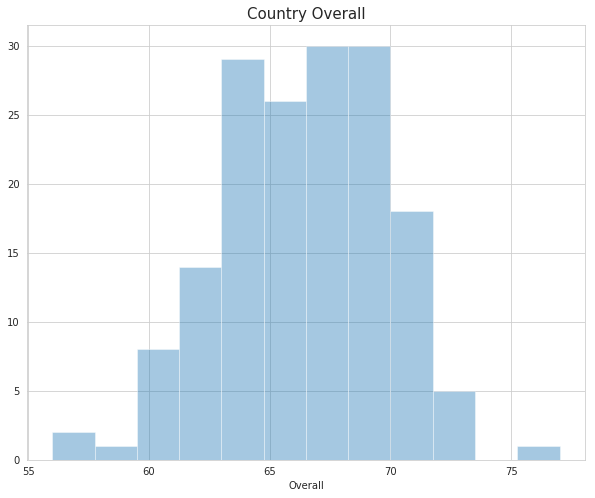

In [10]:
#Country Overall
nat= df.groupby('Nationality')['Overall'].mean()
nat_ovr= pd.DataFrame(nat)
nat_ovr.reset_index()

#Plotting
plt.figure(figsize = (10,8))
sns.distplot(a= nat_ovr['Overall'], kde= False)
plt.title('Country Overall', fontsize= 15)
plt.show()

***What's The Preferred Foot?***

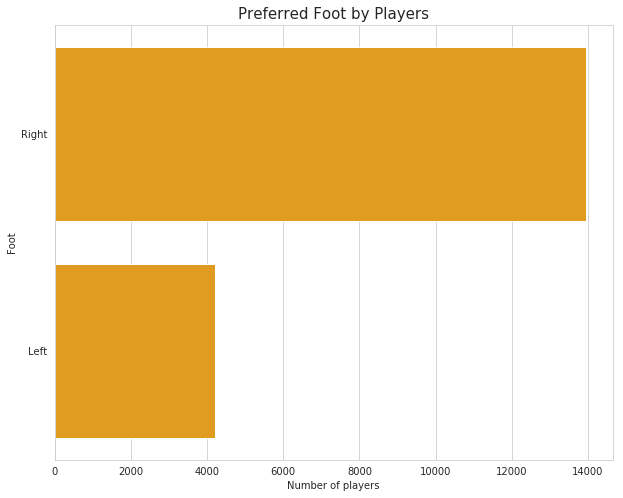

In [11]:
#Preferred Foot By Players
preferred =  df.Preferred_Foot.value_counts()
group3 = pd.DataFrame(preferred)
group3.reset_index(level=0, inplace=True) 
foot = group3.rename(columns={'index': 'Foot', 'Preferred_Foot': 'Number of players'})

#Plotting
plt.figure(figsize = (10,8))
sns.barplot(data= foot, x= 'Number of players', y= 'Foot' , color= 'orange')
plt.title('Preferred Foot by Players', fontsize= 15)
sns.set_style("whitegrid")
plt.show()

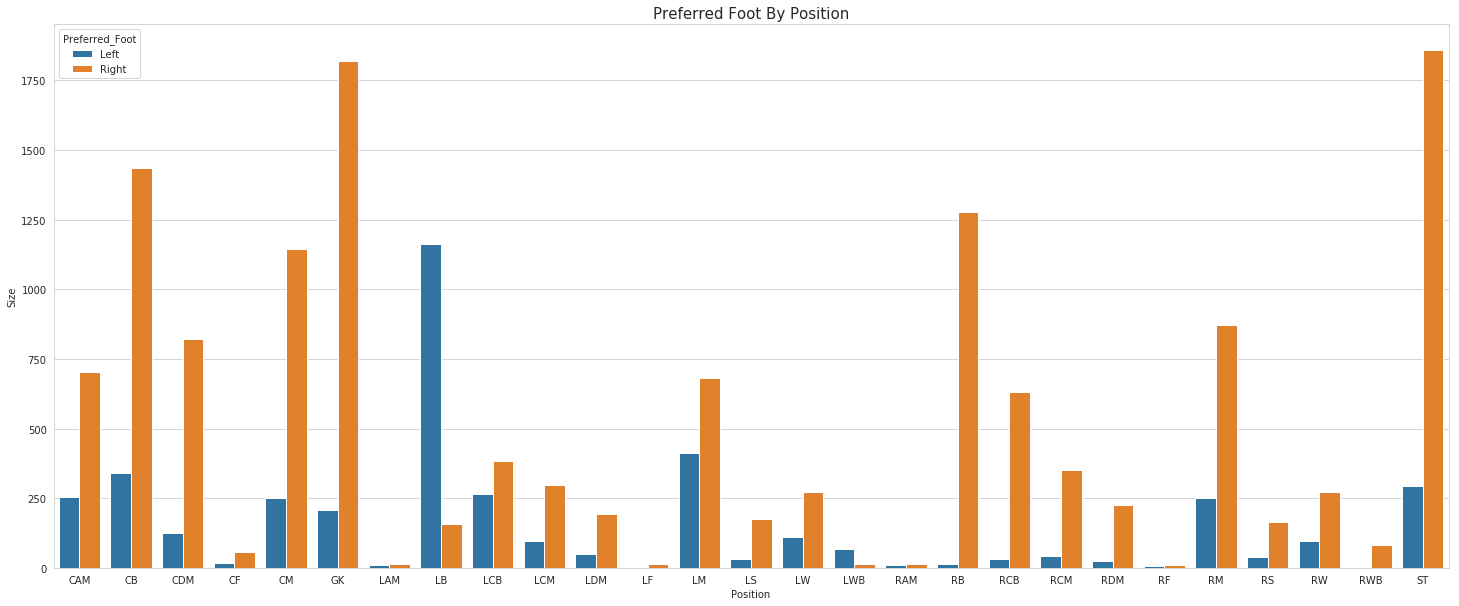

In [12]:
#Preferred Foot By Position
df_pf= df.groupby(['Preferred_Foot', 'Position']).size()
df2= pd.DataFrame(df_pf)
df3= df2.reset_index()
df3.rename(columns={0: 'Size'}, inplace=True)
df3.set_index('Preferred_Foot')

#Plotting
plt.figure(figsize = (25,10))
sns.barplot(x='Position', y="Size", hue='Preferred_Foot', data=df3) 
plt.title('Preferred Foot By Position', fontsize=15)
sns.set_style("whitegrid")
plt.show()

***Let's Explore Players Age***

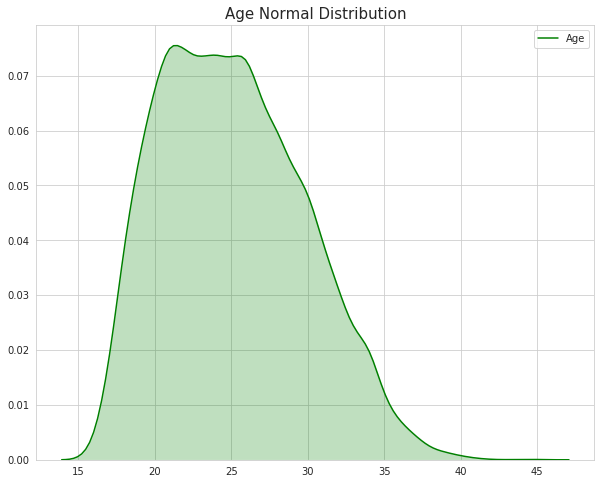

In [13]:
#Age Normal Distribution
plt.figure(figsize= (10,8))
sns.kdeplot(data=data['Age'], shade=True, color= 'green')
plt.title('Age Normal Distribution', fontsize=15)
sns.set_style("whitegrid")
plt.legend()
plt.show()

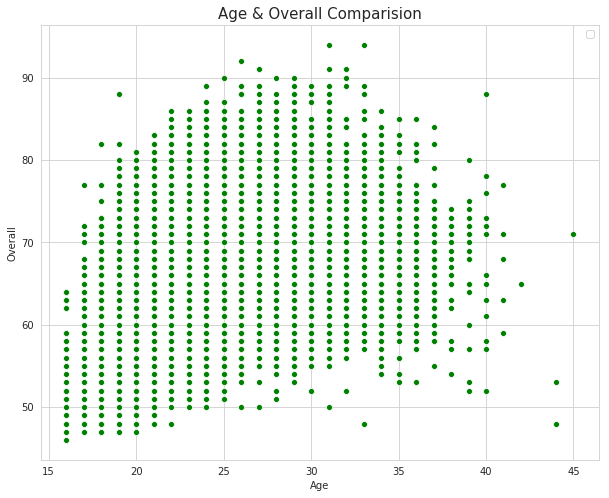

In [14]:
#Age & Overall Comparision
plt.figure(figsize= (10,8))
sns.scatterplot(x=df['Age'], y=df['Overall'], color= 'green')
plt.title('Age & Overall Comparision', fontsize=15)
plt.legend()
plt.show()

#If we take a look, the most 80+ players are found between 20-35 y/o.

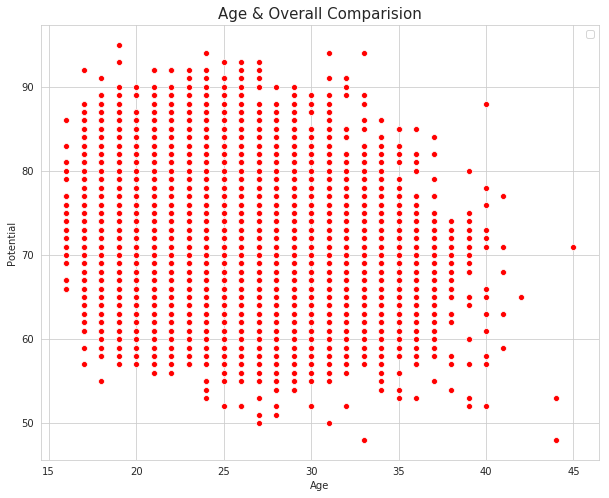

In [15]:
#Age & Potential
plt.figure(figsize= (10,8))
sns.scatterplot(x=df['Age'], y=df['Potential'], color= 'red')
plt.title('Age & Overall Comparision', fontsize=15)
plt.legend()
plt.show()